# Tennis Ball Tracking — Step-by-Step Explainer

Each section explains one stage of the pipeline with plots showing what survives and what gets removed.
Change `FRAME` in Cell 1 to explore different moments.

In [7]:
import sys, cv2, numpy as np, matplotlib.pyplot as plt
import matplotlib.patches as mpatches

sys.path.insert(0, r"C:\ThatFamily Dropbox\Sorin Jayaweera\allSaves\mudd\junior\Digital Signal Processing\code\TENNIS\\claude")
from interactive_viewer import (
    get_cap, read_gray_small, detect, make_prior_image,
    collect_tree_blobs, build_path_dp, make_tree_image,
    collect_track_blobs, make_track_image, parabolic_quality,
    compute_prior_map,
    VIDEO_DIR, REF_W, REF_H,
)

VIDEO_NAME   = "Raja vs Wijemanne Edited.mp4"
FRAME_HIT    = 69#173   # a frame with a clear ball in the air
FRAME_NO_BALL = 50   # a frame with no ball visible
FRAME  = FRAME_HIT
PROC_W = 320
PROC_H = PROC_W * 9 // 16

THRESH       = 10
MIN_A        = 2
MAX_A        = 80
MAX_ASP      = 3.0
MIN_CIRC     = 0.2
MIN_BRIGHT   = 0.0
SCORE_THRESH = 0.10
METHOD       = "compactness"
BALL_DIAM    = 10.0
GAP          = 2

cap = get_cap(VIDEO_NAME)
print(f"Video: {VIDEO_NAME}  frames={int(cap.get(cv2.CAP_PROP_FRAME_COUNT))}  fps={cap.get(cv2.CAP_PROP_FPS):.1f}")
print(f"Analysing FRAME={FRAME}")


Video: Raja vs Wijemanne Edited.mp4  frames=32531  fps=30.0
Analysing FRAME=69


## Step 1 — Load a Frame

Ball detection uses **frame differencing**: subtracting consecutive frames so only *moving* pixels light up.
A tennis ball at 150 km/h moves ~8 px/frame at 25 fps — a small but bright blob in the diff image.
The `GAP` parameter controls how many frames apart the two frames are.

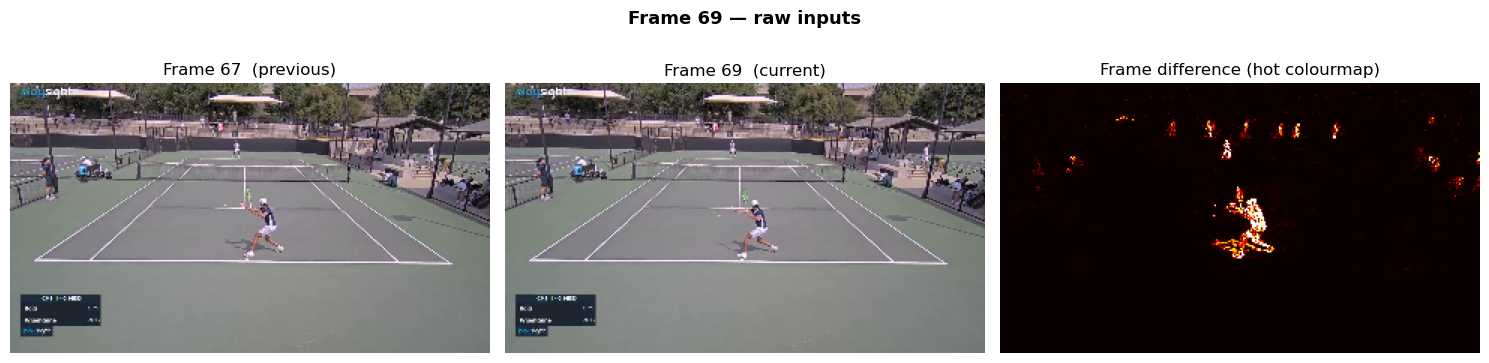

Diff max=207  mean=0.75  pixels>10: 801


In [8]:
gray_curr, bgr_curr = read_gray_small(VIDEO_NAME, FRAME, PROC_W)
gray_prev, bgr_prev = read_gray_small(VIDEO_NAME, max(0, FRAME - GAP), PROC_W)
diff = cv2.absdiff(gray_curr, gray_prev)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f'Frame {FRAME} — raw inputs', fontsize=13, fontweight='bold')
axes[0].imshow(cv2.cvtColor(bgr_prev, cv2.COLOR_BGR2RGB))
axes[0].set_title(f'Frame {FRAME-GAP}  (previous)'); axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(bgr_curr, cv2.COLOR_BGR2RGB))
axes[1].set_title(f'Frame {FRAME}  (current)'); axes[1].axis('off')
axes[2].imshow(diff, cmap='hot', vmin=0, vmax=60)
axes[2].set_title('Frame difference (hot colourmap)'); axes[2].axis('off')
plt.tight_layout(); plt.show()
print(f"Diff max={diff.max()}  mean={diff.mean():.2f}  pixels>{THRESH}: {(diff>THRESH).sum()}")


## Step 2 — Blob Detection & Filters

Connected bright regions in the diff image are **blobs**. Each is tested against six filters:

| Filter | Removes |
|--------|--------|
| `thresh` | dim background noise |
| `min_a` / `max_a` | single-pixel sparks and large shadows/players |
| `max_asp` | elongated motion-blur streaks |
| `min_circ` | non-round blobs (lines, L-shapes). Circularity = 4π·Area/Perimeter² |
| `min_bright` | dim blobs on the court surface |
| `score_thresh` | composite score below threshold |


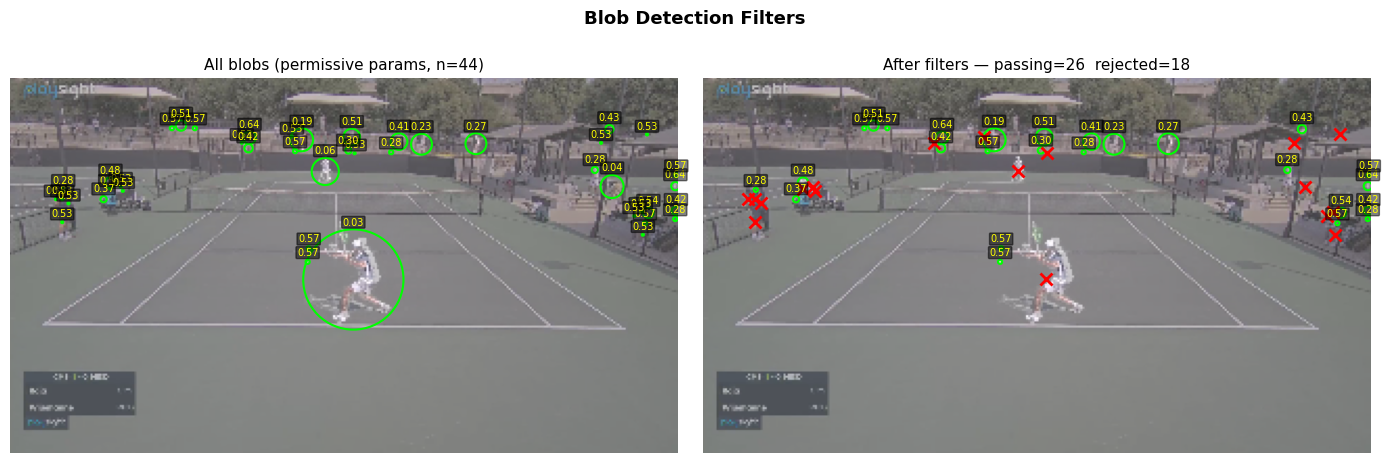

All blobs: 44  passing: 26  rejected: 18


In [9]:
# detect() returns (diff_img, bw, labels, passing_blobs, rejected_blobs)
# Blobs have keys: x, y, x0, y0, w, h, area, asp, score, prior, circ
# radius = max(b['w'], b['h']) / 2

_, _, _, all_pass_perm, all_rej_perm = detect(
    gray_curr, gray_prev,
    thresh=THRESH, min_a=1, max_a=9999, max_asp=99.0,
    method=METHOD, score_thresh=0.0,
    ball_diam=BALL_DIAM, min_circ=0.0, min_bright=0.0,
)
all_blobs = all_pass_perm + all_rej_perm

_, _, _, passing, rejected = detect(
    gray_curr, gray_prev,
    thresh=THRESH, min_a=MIN_A, max_a=MAX_A, max_asp=MAX_ASP,
    method=METHOD, score_thresh=SCORE_THRESH,
    ball_diam=BALL_DIAM, min_circ=MIN_CIRC, min_bright=MIN_BRIGHT,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Blob Detection Filters', fontsize=13, fontweight='bold')
for ax, title, green_blobs, red_blobs in [
    (axes[0], f'All blobs (permissive params, n={len(all_blobs)})', all_blobs, []),
    (axes[1], f'After filters — passing={len(passing)}  rejected={len(rejected)}',
     passing, rejected),
]:
    ax.imshow(diff, cmap='gray', vmin=0, vmax=60, alpha=0.5)
    ax.imshow(cv2.cvtColor(bgr_curr, cv2.COLOR_BGR2RGB), alpha=0.5)
    for b in green_blobs:
        r = max(b['w'], b['h']) / 2
        ax.add_patch(plt.Circle((b['x'],b['y']),r,fill=False,color='lime',lw=1.5))
        ax.text(b['x'],b['y']-r-2,f"{b['score']:.2f}",
                color='yellow',fontsize=7,ha='center',
                bbox=dict(boxstyle='round,pad=0.1',fc='black',alpha=0.5))
    for b in red_blobs:
        ax.plot(b['x'],b['y'],'rx',ms=8,mew=2)
    ax.set_title(title,fontsize=11)
    ax.set_xlim(0,PROC_W); ax.set_ylim(PROC_H,0); ax.axis('off')
plt.tight_layout(); plt.show()
print(f"All blobs: {len(all_blobs)}  passing: {len(passing)}  rejected: {len(rejected)}")


## Step 3 — Spatial Prior

The **spatial prior** is a Gaussian heatmap biasing scores toward the expected ball region (air above net).

> `score_final = score_raw × (weight × prior_value + (1 − weight))`

Setting `weight=0` disables the prior. Two overlapping Gaussians cover the court plane and the air region.
When `use_prior=True`, blobs in low-probability zones (e.g. below the court baseline) get their scores
multiplied down — use a non-zero `SCORE_THRESH` to hard-reject them.


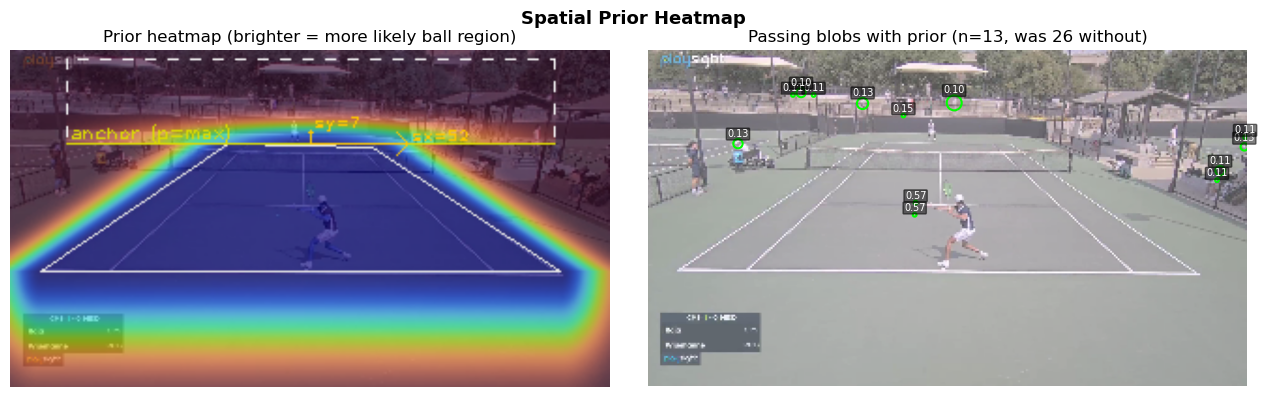

In [10]:
prior_map = compute_prior_map(
    court_x_sigma=15, court_y_sigma=25,
    air_x_left=30, air_x_right=290, air_y_top=5, air_y_bot=50,
    air_sigma_x=52, air_sigma_y=7, weight=0.8,
)

prior_img = make_prior_image(
    court_x_sigma=15, court_y_sigma=25,
    air_x_left=30, air_x_right=290, air_y_top=5, air_y_bot=50,
    air_sigma_x=52, air_sigma_y=7, weight=0.8,
    vname=VIDEO_NAME, frame_idx=FRAME, frame_blend=0.35,
)

# Re-run detection WITH the prior so scores below-court get multiplied down
_, _, _, passing_prior, rejected_prior = detect(
    gray_curr, gray_prev,
    thresh=THRESH, min_a=MIN_A, max_a=MAX_A, max_asp=MAX_ASP,
    method=METHOD, score_thresh=SCORE_THRESH,
    ball_diam=BALL_DIAM, min_circ=MIN_CIRC, min_bright=MIN_BRIGHT,
    prior_map=prior_map,
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Spatial Prior Heatmap', fontsize=13, fontweight='bold')
axes[0].imshow(cv2.cvtColor(prior_img, cv2.COLOR_BGR2RGB))
axes[0].set_title('Prior heatmap (brighter = more likely ball region)'); axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(bgr_curr, cv2.COLOR_BGR2RGB), alpha=0.7)
for b in passing_prior:
    r = max(b['w'], b['h']) / 2
    axes[1].add_patch(plt.Circle((b['x'],b['y']),r,fill=False,color='lime',lw=1.5))
    axes[1].text(b['x'],b['y']-r-1,f"{b['score']:.2f}",color='white',fontsize=7,ha='center',
                 bbox=dict(boxstyle='round,pad=0.1',fc='black',alpha=0.5))
axes[1].set_title(f'Passing blobs with prior (n={len(passing_prior)}, was {len(passing)} without)')
axes[1].set_xlim(0,PROC_W); axes[1].set_ylim(PROC_H,0); axes[1].axis('off')
plt.tight_layout(); plt.show()


## Step 4 — Trajectory Tree (DP Linking)

One frame can't confirm the ball — multiple candidates exist. We look at a **window of frames** and use **dynamic programming** to link blobs across time, minimising:

> **cost = Σ distance(bᵢ, bᵢ₊₁) + vel_penalty × |Δvelocity|²**

The velocity penalty discourages sudden direction changes. Blobs stationary across frames are flagged as artefacts and excluded.


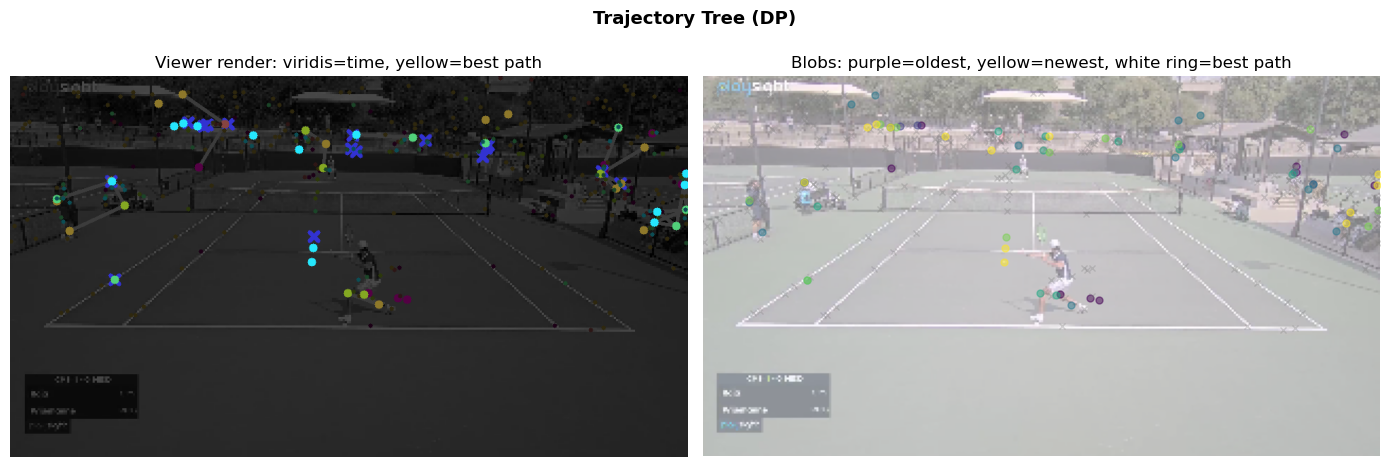

Steps=6  blobs=422  path=0


In [11]:
tree_steps = collect_tree_blobs(
    vname=VIDEO_NAME, center_frame=FRAME, gap=GAP, n_steps=6, proc_w=PROC_W,
    thresh=THRESH, min_a=MIN_A, max_a=MAX_A, max_asp=MAX_ASP,
    method=METHOD, ball_diam=BALL_DIAM,
    min_circ=MIN_CIRC, min_bright=MIN_BRIGHT, score_thresh=SCORE_THRESH,
    prior_map=prior_map,   # spatial prior applied here too
)
chron, static_flags, edges, best_path = build_path_dp(
    tree_steps, link_radius=30, static_radius=8, vel_penalty=0.05,
)

tree_img = make_tree_image(VIDEO_NAME, FRAME, PROC_W, chron, static_flags, edges, best_path)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Trajectory Tree (DP)', fontsize=13, fontweight='bold')
axes[0].imshow(cv2.cvtColor(tree_img, cv2.COLOR_BGR2RGB))
axes[0].set_title('Viewer render: viridis=time, yellow=best path'); axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(bgr_curr, cv2.COLOR_BGR2RGB), alpha=0.5)
cmap = plt.cm.viridis; n_t = len(chron); path_set = set(best_path)
for t, step in enumerate(chron):
    col = cmap(t / max(n_t-1,1))
    for i, b in enumerate(step['blobs']):
        if (t,i) in path_set:
            axes[1].plot(b['x'],b['y'],'o',color=col,ms=10,
                         markeredgecolor='white',markeredgewidth=1.5,zorder=5)
        elif b.get('passing',True):
            axes[1].plot(b['x'],b['y'],'o',color=col,ms=5,alpha=0.5)
        else:
            axes[1].plot(b['x'],b['y'],'x',color='gray',ms=4,alpha=0.3)
if len(best_path) > 1:
    px=[chron[t]['blobs'][i]['x'] for t,i in best_path]
    py=[chron[t]['blobs'][i]['y'] for t,i in best_path]
    axes[1].plot(px,py,'w--',lw=1.5,alpha=0.8,label='Best path'); axes[1].legend(fontsize=9)
axes[1].set_title('Blobs: purple=oldest, yellow=newest, white ring=best path')
axes[1].set_xlim(0,PROC_W); axes[1].set_ylim(PROC_H,0); axes[1].axis('off')
plt.tight_layout(); plt.show()
print(f"Steps={len(chron)}  blobs={sum(len(s['blobs']) for s in chron)}  path={len(best_path)}")


## Step 5 — Parabolic Path Quality (R²)

A real ball follows a **parabolic arc** under gravity. We fit a degree-2 polynomial and compute R²:

> R² = 1 − SS_res / SS_tot

- R² ≈ 1.0 → positions lie on a parabola → likely the real ball
- R² ≈ 0.0 → scattered noise or a non-ball object

We fit both **y = f(x)** (used by `parabolic_quality`) and **y = f(t)** (more robust when the ball moves mostly vertically).


In [12]:
layers_track = collect_track_blobs(
    vname=VIDEO_NAME, center_frame=FRAME, proc_w=PROC_W,
    n_look=12, top_k=3,
    thresh=THRESH, min_a=MIN_A, max_a=MAX_A, max_asp=MAX_ASP,
    method=METHOD, ball_diam=BALL_DIAM,
    min_circ=MIN_CIRC, min_bright=MIN_BRIGHT,
    blur_k=0, score_thresh=SCORE_THRESH,
    prior_map=prior_map,   # spatial prior applied here too
)
steps_nf = list(reversed(layers_track))
chron_track, _, _, best_track = build_path_dp(
    steps_nf, link_radius=40, static_radius=8, vel_penalty=0.03,
)
r2 = parabolic_quality(chron_track, best_track)

if len(best_track) >= 3:
    xs = np.array([chron_track[t]['blobs'][i]['x'] for t,i in best_track])
    ys = np.array([chron_track[t]['blobs'][i]['y'] for t,i in best_track])
    ts = np.arange(len(xs), dtype=float)
    coeffs_xy = np.polyfit(xs, ys, 2)
    y_pred_xy = np.polyval(coeffs_xy, xs)
    ss_res = np.sum((ys-y_pred_xy)**2); ss_tot = np.sum((ys-ys.mean())**2)
    r2_xy  = max(0.0, 1 - ss_res / max(ss_tot, 1e-6))
    coeffs_t  = np.polyfit(ts, ys, 2)
    y_pred_t  = np.polyval(coeffs_t, ts)
    r2_t      = max(0.0, 1 - np.sum((ys-y_pred_t)**2) / max(ss_tot, 1e-6))
    xs_dense = np.linspace(xs.min(), xs.max(), 200) if xs.max()>xs.min() else xs
    ys_dense = np.polyval(coeffs_xy, xs_dense)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(
        f'Parabolic Path Quality   '
        f'R²(y vs x)={r2_xy:.3f}   R²(y vs t)={r2_t:.3f}',
        fontsize=13, fontweight='bold')

    axes[0].imshow(cv2.cvtColor(bgr_curr, cv2.COLOR_BGR2RGB), alpha=0.7)
    sc = axes[0].scatter(xs, ys, c=ts, cmap='viridis', s=100,
                         edgecolors='white', lw=1.5, zorder=5, label='Path blobs')
    if xs.max() > xs.min():
        axes[0].plot(xs_dense, ys_dense, 'm--', lw=2, label='Parabola y=f(x)')
    plt.colorbar(sc, ax=axes[0], fraction=0.046, label='Time index')
    axes[0].set_title('Path on frame'); axes[0].set_xlim(0,PROC_W); axes[0].set_ylim(PROC_H,0)
    axes[0].legend(fontsize=8)

    axes[1].axhline(0,color='gray',ls='--',lw=1)
    axes[1].bar(range(len(ys-y_pred_xy)), ys-y_pred_xy, color='salmon', edgecolor='k', lw=0.5)
    axes[1].set_title(f'Residuals y−parabola(x)  R²={r2_xy:.3f}')
    axes[1].set_xlabel('Node index'); axes[1].set_ylabel('Residual (px)')

    axes[2].axhline(0,color='gray',ls='--',lw=1)
    axes[2].bar(range(len(ys-y_pred_t)), ys-y_pred_t, color='skyblue', edgecolor='k', lw=0.5)
    axes[2].set_title(f'Residuals y−parabola(t)  R²={r2_t:.3f}')
    axes[2].set_xlabel('Node index'); axes[2].set_ylabel('Residual (px)')

    plt.tight_layout(); plt.show()
    print(f"Path={len(best_track)} nodes  R²(x)={r2_xy:.3f}  R²(t)={r2_t:.3f}")
    msg = ('✓ High — genuine arc' if r2_xy>=0.85
           else '~ Moderate' if r2_xy>=0.5 else '✗ Low — likely noise')
    print(f"Quality: {msg}")
else:
    print(f"Path too short ({len(best_track)} nodes) — change FRAME to one with more ball visibility")
    print(f"parabolic_quality = {r2:.3f}")


Path too short (0 nodes) — change FRAME to one with more ball visibility
parabolic_quality = 0.000
